`from sklearn.linear_model import LogisticRegression` <br><br>

`model = LogisticRegression()`        # 1. create the model <br>
`model.fit(X_train, y_train)`         # 2. train it <br>
`predictions = model.predict(X_test)` # 3. make predictions <br>
`score = model.score(X_test, y_test)` # 4. evaluate it

# Day 1: Preprocessing

In [141]:
np.random.seed(42)

# Create dataset
df = pd.DataFrame({
    'voltage':     np.random.normal(3.7, 0.2, 500),
    'current':     np.random.normal(10.0, 1.5, 500),
    'temperature': np.random.normal(25.0, 3.0, 500),
    'fault':       np.random.randint(0, 2, 500)
})

# Features and target
X = df[['voltage', 'current', 'temperature']].values
y = df['fault'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dataset size:", len(df))
print("Class distribution:", np.bincount(y))
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Dataset size: 500
Class distribution: [238 262]
Training samples: 400
Test samples: 100


## Train/Test Split:

1. Training set — the model learns from this (typically 80%)
2. Test set — you evaluate the model on this (typically 20%)

In [142]:
#from sklearn.model_selection import train_test_split

#X = df[['voltage', 'current', 'temperature']].values   # features
#y = df['fault'].values                                  # target

#X_train, X_test, y_train, y_test = train_test_split(
 #   X, y,
  #  test_size=0.2,      # 20% goes to test set
  #  random_state=42     # same as np.random.seed — reproducibility
#)

#print("Training samples:", len(X_train))
#print("Test samples:", len(X_test))

X is always features, the columns your model uses to make predictions. <br> 
y is always the target, what you're trying to predict. <br>
This naming convention is universal across all of ML.

## Feature Scaling
- Z-score normalization done automatically with `StandardScalar`

The critical rule: **fit only on training data, never on test data.** If you fit the scaler on the full dataset before splitting, information from the test set leaks into the training process. This is called **data leakage** and it's one of the most common ML mistakes.

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std AND transform
X_test_scaled  = scaler.transform(X_test)         # only transform, don't relearn

X_train, X_test = train_test_split(X)
scaler.fit_transform(X_train)     # only sees training data
scaler.transform(X_test)          # applies same scaling, no refitting

array([[ 6.17396032e-01, -4.47581932e-01, -1.29076018e+00],
       [-6.12450645e-01,  2.49957138e-01, -1.31309807e-01],
       [ 2.33072928e+00,  2.86482383e-01, -1.26947480e+00],
       [ 2.01841345e-01, -1.11397406e+00, -7.04758920e-01],
       [ 9.73559810e-01, -4.48386253e-01, -4.82474343e-01],
       [-1.47036185e+00, -5.91049347e-01,  4.61320817e-01],
       [-9.46960502e-01, -1.04443958e+00, -3.60657693e-01],
       [-5.66862094e-01, -7.93517524e-01,  1.53867997e+00],
       [-3.40858417e-01, -1.03057449e+00, -4.16830633e-01],
       [ 7.08488622e-01,  6.95060781e-01,  7.80782823e-01],
       [-8.08953490e-01,  8.06152422e-01,  1.02035476e+00],
       [-2.02950759e+00,  1.12941144e+00,  6.93556577e-01],
       [-1.64960018e+00,  7.25579039e-01,  2.73150811e-01],
       [ 6.27327366e-01,  4.52653468e-01,  1.45349889e+00],
       [ 8.08683254e-01,  4.66644656e-03,  1.32117213e-01],
       [ 1.52852208e+00, -1.03386772e+00,  1.36005222e+00],
       [-6.68957419e-01, -3.78335457e-01

## Encoding Categorical Variables

- ML models only understand numbers. If you have text columns like Compound (SOFT, MEDIUM, HARD) you need to convert them to numbers first.

### Label Encoding — converts each category to an integer:

In [144]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df['Compound_encoded'] = le.fit_transform(df['Compound'])
# HARD → 0, MEDIUM → 1, SOFT → 2

### One-Hot Encoding — creates a separate binary column per category:

In [145]:
#from sklearn.preprocessing import OneHotEncoder
#import pandas as pd

#encoded = pd.get_dummies(df['Compound'], prefix='Compound')
#df = pd.concat([df, encoded], axis=1)

#    Compound_HARD  Compound_MEDIUM  Compound_SOFT
# 0              0                0              1
# 1              0                1              0
# 2              1                0              0

## Full Preprocessing Pipeline

In [146]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Data ──────────────────────────────────────────────
df = pd.DataFrame({
    'voltage':     np.random.normal(3.7, 0.2, 500),
    'current':     np.random.normal(10.0, 1.5, 500),
    'temperature': np.random.normal(25.0, 3.0, 500),
    'fault':       np.random.randint(0, 2, 500)
})

X = df[['voltage', 'current', 'temperature']].values
y = df['fault'].values

# ── Split ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scale ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Dataset size:", len(df))
print("Class distribution:", np.bincount(y))
print("X_train:", X_train_scaled.shape)
print("X_test: ", X_test_scaled.shape)
print("All variables ready")

Dataset size: 500
Class distribution: [238 262]
X_train: (400, 3)
X_test:  (100, 3)
All variables ready


# Day 2: Training a model

## Model 1: Logistic Regression
- It predicts a category (0 or 1) not a continuous number. It's the simplest classification model and always the right starting point.
-  it draws a line (or hyperplane in multiple dimensions) that separates class 0 from class 1. New data points that fall on one side get predicted as 0, the other side as 1.

In [147]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)
print("Predictions:", predictions)
print("Actual:     ", y_test)
print("Accuracy:", model.score(X_test_scaled, y_test))

Predictions: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0
 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1
 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 0 0]
Actual:      [1 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 0 0 1 0 0 1 1 1 1 0 1 0 1 0
 1 0 1 1 1 1 0 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 0]
Accuracy: 0.48


## Model 2: Decision Tree

- Learns a series of if/else rules from the data:
- max_depth=3 limits how many levels of if/else the tree can make. Without this it memorises the training data perfectly but fails on new data (overfitting).


In [148]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train_scaled, y_train)

print("Accuracy:", model.score(X_test_scaled, y_test))

Accuracy: 0.53


Visualization

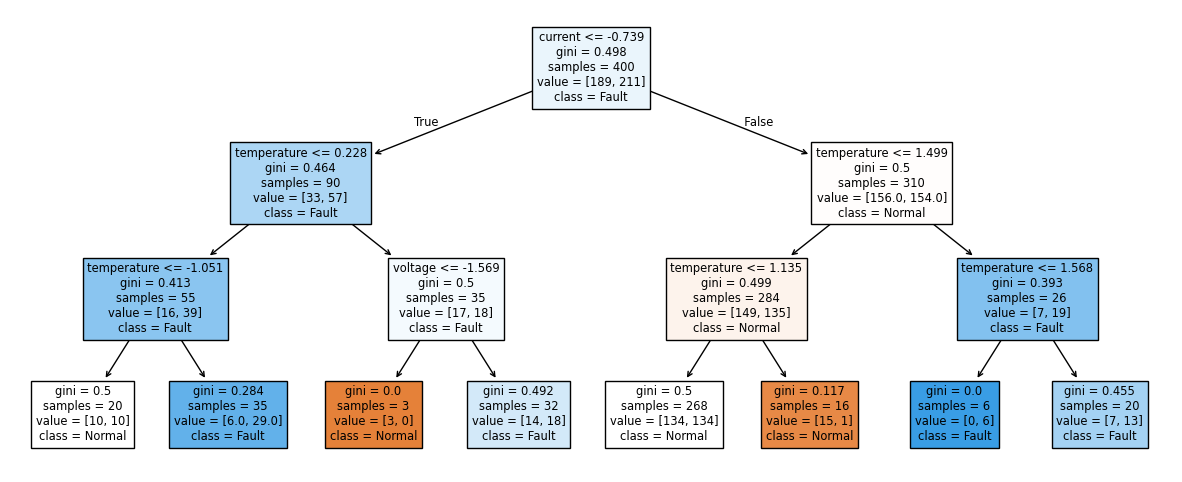

In [149]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plot_tree(model, feature_names=['voltage', 'current', 'temperature'],
          class_names=['Normal', 'Fault'], filled=True)
plt.show()

## Model 3 - Random Forest
- Takes many decision trees, trains each on a random subset of the data, and combines their votes. Almost always outperforms a single tree.
- Random Forest is the default model. When in doubt, start here. It handles messy data, doesn't need much tuning, and is hard to break.
- n_estimators=100 means 100 trees vote on each prediction. feature_importances_ tells which features the model relied on most

In [150]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

print("Accuracy:", model.score(X_test_scaled, y_test))

# Bonus — feature importance
importance = model.feature_importances_
for name, imp in zip(['voltage', 'current', 'temperature'], importance):
    print(f"  {name}: {imp:.3f}")

Accuracy: 0.57
  voltage: 0.327
  current: 0.324
  temperature: 0.349


## Model 4: Linear Regression
- When you want to predict a number rather than a category:


In [151]:
from sklearn.linear_model import LinearRegression

# Example: predict lap time from tyre life and grid position
model = LinearRegression()
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

# Evaluation for regression uses different metrics
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

print("RMSE:", root_mean_squared_error(y_test, predictions))
print("MAE: ", mean_absolute_error(y_test, predictions))
print("R²:  ", r2_score(y_test, predictions))

RMSE: 0.5018784920487066
MAE:  0.4998058670687723
R²:   -0.007931255626585143


# Day 3: Evaluation


- Switching back to a classifier

In [152]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

## The Confusion Matrix

- True Positive (TP) — fault predicted, fault actual ✅
- True Negative (TN) — normal predicted, normal actual ✅
- False Positive (FP) — fault predicted, actually normal ❌ (false alarm)
- False Negative (FN) — normal predicted, actually fault ❌ (missed fault — dangerous)

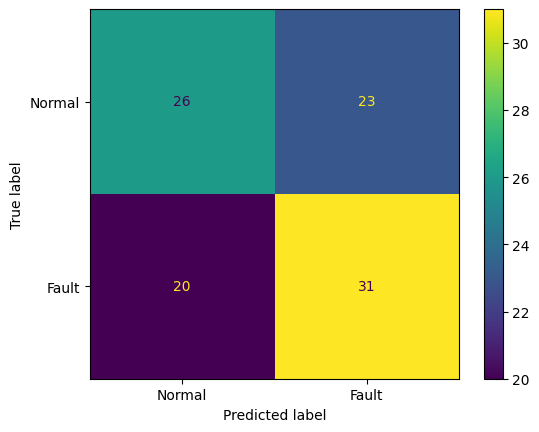

In [153]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Normal', 'Fault'])
disp.plot()
plt.show()

## Classification Report
- F1 Score — harmonic mean of precision and recall. Use this as your main metric when classes are imbalanced.

**Precision** — of all the times you predicted fault, how often were you right? <br>
Precision = TP / (TP + FP) <br><br>
**Recall** — of all the actual faults, how many did you catch? <br>
Recall = TP / (TP + FN)

When to prioritise which:

- Medical diagnosis / fault detection → prioritise Recall — missing a real fault is worse than a false alarm
- Spam filter → prioritise Precision — a false alarm (good email in spam) is worse than missing spam

In [154]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, 
                             target_names=['Normal', 'Fault']))

              precision    recall  f1-score   support

      Normal       0.57      0.53      0.55        49
       Fault       0.57      0.61      0.59        51

    accuracy                           0.57       100
   macro avg       0.57      0.57      0.57       100
weighted avg       0.57      0.57      0.57       100



## Regression Metrics

- When predicting continuous values:


In [155]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# RMSE — average error in same units as target
rmse = root_mean_squared_error(y_test, predictions)

# MAE — average absolute error, less sensitive to outliers
mae = mean_absolute_error(y_test, predictions)

# R² — how much variance the model explains (1.0 = perfect, 0 = useless)
r2 = r2_score(y_test, predictions)

print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"R²:   {r2:.3f}")

RMSE: 0.656
MAE:  0.430
R²:   -0.721


## Cross Validation

- A single train/test split can get lucky or unlucky depending on which rows ended up in each set. Cross validation solves this by splitting the data multiple times and averagin

- `cv=5` means 5 splits, the data is divided into 5 chunks, the model trains on 4 and tests on 1, rotating through all combinations. The average score is a much more reliable performance estimate than a single split.

In [156]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Scores per fold:", scores.round(3))
print("Mean accuracy:  ", scores.mean().round(3))
print("Std deviation:  ", scores.std().round(3))

Scores per fold: [0.54 0.5  0.54 0.56 0.54]
Mean accuracy:   0.536
Std deviation:   0.02


# Putting it all together

In [158]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

# 1. Load and prepare data
X = df[['voltage', 'current', 'temperature']].values
y = df['fault'].values

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Train multiple models and compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {'Test Accuracy': score, 'CV Accuracy': cv_score}
    print(f"{name}: Test={score:.3f}, CV={cv_score:.3f}")

# 5. Pick best model and evaluate properly
best_model = models['Random Forest']
predictions = best_model.predict(X_test_scaled)
print(classification_report(y_test, predictions))

Logistic Regression: Test=0.480, CV=0.487
Decision Tree: Test=0.530, CV=0.487
Random Forest: Test=0.570, CV=0.482
              precision    recall  f1-score   support

           0       0.57      0.53      0.55        49
           1       0.57      0.61      0.59        51

    accuracy                           0.57       100
   macro avg       0.57      0.57      0.57       100
weighted avg       0.57      0.57      0.57       100

